In [ ]:
#Developed in Google Colab; update project_path if running elsewhere
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/BugPrioritization/bugzilla_processed.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Intelligent Bug Prioritization System

# Project Summary

Predict bug priority from Bugzilla bug reports and support a practical triage decision: **which bugs should be routed to an urgent queue for human review?**

### Key Results

| Metric | Result |
|---|---:|
| Dataset | 9,998 bug reports |
| Priority Classes | P1–P5 |
| Majority-Class Baseline | **65.65%** |
| Initial Multiclass Accuracy | **68.95%** |
| Tuned Multiclass Accuracy | **66.75%** |
| Tuned Multiclass Macro-F1 | **0.326** |
| Binary Framing | **P1/P2 = Urgent, P3/P4/P5 = Normal** |
| Binary Accuracy | **85.90%** |
| Default Urgent Recall (threshold 0.50) | **12.37%** |
| 80% Recall Threshold | **0.097** |
| Urgent Recall at 0.097 | **80.07%** |
| Precision at 0.097 | **24.35%** |
| Cost-Minimizing Threshold | **0.08** |
| Urgent Recall at 0.08 | **87.29%** |
| Precision at 0.08 | **21.71%** |
| Cost at 0.08 | **1,286** |

### Final Product Decision

Rather than optimizing for overall accuracy, the system is treated as a **decision-support tool for bug triage**.  
The final operating threshold can be selected based on the business objective: **0.097 targets ≥80% urgent recall, while 0.08 minimizes the assumed cost of false negatives and false positives.**

### Cost Assumption

For the cost-sensitive analysis:

- False Negative (missed urgent bug) = **10 cost units**
- False Positive (unnecessary urgent review) = **1 cost unit**

**Total Cost = 10 × FN + 1 × FP**

> The cost ratio is an explicit modeling assumption for demonstrating cost-sensitive deployment. In production, these costs should be calibrated using actual incident severity and triage effort.

In [ ]:
# Create numerical features again
df["summary_length"] = df["Summary"].str.len()

df["word_count"] = df["Summary"].str.split().str.len()

# Verify
df[["summary_length", "word_count"]].head()

,summary_length,word_count
0,56,8
1,85,12
2,86,13
3,69,7
4,76,7


# XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees. Unlike Logistic Regression, it can capture complex non-linear relationships and feature interactions, making it well suited for bug priority prediction using both textual and structured features.

In [ ]:
!pip install -q xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
text_feature = "clean_summary"

categorical_features = [
    "Type",
    "Component",
    "OS",
    "Version"
]

numerical_features = [
    "summary_length",
    "word_count"
]

target = "Priority"

## Train/Test Split

The data is split into training and test sets so that model performance is evaluated on previously unseen bug reports.  The test set is kept separate from model fitting and hyperparameter selection to reduce evaluation bias.

*Evaluation used a random split rather than a time-based split; real-world performance on genuinely future bugs may differ.*

In [ ]:
X = df[
    ["Summary"] +
    [text_feature] +
    categorical_features +
    numerical_features
]

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Text Representation — TF-IDF

TF-IDF converts bug summaries into numerical features while emphasizing terms that are informative within the corpus.  
It provides a strong and interpretable baseline for bug-text classification without requiring a large language model.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X_train_text = tfidf.fit_transform(
    X_train["clean_summary"]
)

X_test_text = tfidf.transform(
    X_test["clean_summary"]
)

## Structured Feature Encoding

Categorical fields such as bug type, component, operating system, and version are one-hot encoded, while numerical text statistics are scaled.  
These features complement TF-IDF by capturing structured patterns that may correlate with historical bug priority.

In [ ]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

In [ ]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

In [ ]:
X_train_final = hstack([
    X_train_text,
    X_train_cat,
    X_train_num
])

X_test_final = hstack([
    X_test_text,
    X_test_cat,
    X_test_num
])

print(X_train_final.shape)
print(X_test_final.shape)

(7998, 5233)
(2000, 5233)


In [ ]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

['P1' 'P2' 'P3' 'P4' 'P5']


## Multiclass Priority Model

The first step is to predict the exact priority class **P1–P5** using XGBoost. This establishes how well the system can reproduce historical priority assignments before considering a simplified operational decision.

In [ ]:
xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=len(label_encoder.classes_),

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    tree_method="hist",

    eval_metric="mlogloss",

    n_jobs=-1
)

xgb.fit(
    X_train_final,
    y_train_encoded
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=5, ...)

In [ ]:
y_pred = xgb.predict(X_test_final)

In [ ]:
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

          P1       0.69      0.15      0.25        60
          P2       0.45      0.06      0.11       231
          P3       0.69      0.97      0.81      1313
          P4       0.67      0.04      0.07        54
          P5       0.74      0.23      0.36       342

    accuracy                           0.69      2000
   macro avg       0.65      0.29      0.32      2000
weighted avg       0.67      0.69      0.61      2000



## Class Imbalance & Baseline

P3 is the dominant class, making overall accuracy potentially misleading, therefore it was compared against the **majority-class baseline** and report Macro-F1, per-class precision/recall, and the confusion matrix.

In [ ]:
print("Accuracy:",
      accuracy_score(y_test_encoded, y_pred))

print("Macro Precision:",
      precision_score(
          y_test_encoded,
          y_pred,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          y_test_encoded,
          y_pred,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          y_test_encoded,
          y_pred,
          average="macro"
      ))

Accuracy: 0.6895
Macro Precision: 0.6483685816179914
Macro Recall: 0.29037165120020775
Macro F1: 0.3172032675266067


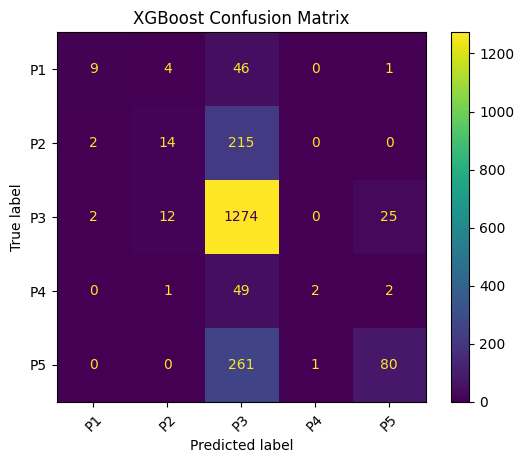

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
feature_names = (
    tfidf.get_feature_names_out().tolist()
    + encoder.get_feature_names_out().tolist()
    + numerical_features
)

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
2038,intermittent,0.005752
5043,Component_Sidebar,0.005145
4059,single tracking,0.004356
5022,Component_Messaging System,0.004256
5004,Component_Bookmarks & History,0.003630
5002,Type_task,0.003615
4422,take screenshot,0.003484
4791,vertical tab,0.003331
5041,Component_Sharing,0.003033
4419,take,0.002897


## XGBoost Results

An XGBoost classifier was trained using the same hybrid feature set as the baseline Logistic Regression model, consisting of TF-IDF features, categorical metadata, and engineered numerical features.

### Performance

- Accuracy: **68.95%**
- Macro Precision: **0.648**
- Macro Recall: **0.290**
- Macro F1-score: **0.317**

Compared to Logistic Regression, XGBoost achieved higher overall accuracy and precision, indicating better performance on the majority class. However, recall for minority priority classes remained low, resulting in a Macro F1-score similar to the baseline.

These findings suggest that while XGBoost effectively models dominant patterns in the data, additional techniques such as contextual text embeddings, class imbalance handling, and model explainability are needed to improve performance on underrepresented bug priorities.

## Hyperparameter Tuning

RandomizedSearchCV with 3-fold cross-validation is used to explore XGBoost hyperparameters efficiently.  
Have to optimize **Macro-F1** rather than accuracy because performance across all priority classes matters more than the dominant P3 class.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [ ]:
param_dist = {

    "n_estimators": randint(200, 700),

    "max_depth": randint(3, 10),

    "learning_rate": uniform(0.01, 0.2),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4),

    "min_child_weight": randint(1, 8),

    "gamma": uniform(0, 0.5),

    "reg_alpha": uniform(0, 1),

    "reg_lambda": uniform(0.5, 2)
}

In [ ]:
xgb_base = XGBClassifier(

    objective="multi:softprob",

    num_class=len(label_encoder.classes_),

    eval_metric="mlogloss",

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

In [ ]:
random_search = RandomizedSearchCV(

    estimator=xgb_base,

    param_distributions=param_dist,

    n_iter=30,

    scoring="f1_macro",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train_final,
    y_train_encoded
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7ba3fa1d7680>,
                                        'reg_alpha': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba404b744d0>,
                                        'reg_lambda': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba3f5288cb0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba40593e430>},
                   random_state=42, scoring='f1_macro', verbose=2)

In [ ]:
print("Best Parameters:\n")

print(random_search.best_params_)

print("\nBest CV Macro F1:")

print(random_search.best_score_)

Best Parameters:

{'colsample_bytree': np.float64(0.7881202537784153), 'gamma': np.float64(0.4917115704474215), 'learning_rate': np.float64(0.08976488848891061), 'max_depth': 9, 'min_child_weight': 1, 'n_estimators': 400, 'reg_alpha': np.float64(0.32078006497173583), 'reg_lambda': np.float64(0.8730370207997085), 'subsample': np.float64(0.6163100566219055)}

Best CV Macro F1:
0.3264505511894163


In [ ]:
best_xgb = random_search.best_estimator_

In [ ]:
y_pred_best = best_xgb.predict(X_test_final)

In [ ]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(classification_report(
    y_test_encoded,
    y_pred_best,
    target_names=label_encoder.classes_
))

print("Accuracy:", accuracy_score(y_test_encoded, y_pred_best))

print("Macro Precision:",
      precision_score(
          y_test_encoded,
          y_pred_best,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          y_test_encoded,
          y_pred_best,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          y_test_encoded,
          y_pred_best,
          average="macro"
      ))

              precision    recall  f1-score   support

          P1       0.50      0.15      0.23        60
          P2       0.34      0.10      0.16       231
          P3       0.69      0.91      0.79      1313
          P4       0.29      0.04      0.07        54
          P5       0.57      0.29      0.38       342

    accuracy                           0.67      2000
   macro avg       0.48      0.30      0.33      2000
weighted avg       0.61      0.67      0.61      2000

Accuracy: 0.6675
Macro Precision: 0.4768155817496069
Macro Recall: 0.29902119747351635
Macro F1: 0.32557484386413754


### Hyperparameter Tuning Summary

RandomizedSearchCV with 3-fold cross-validation was used to tune the multiclass XGBoost baseline using Macro-F1 as the optimization objective. The search explored tree depth, learning rate, number of estimators, sampling ratios, and regularization parameters.

The tuned model achieved a test Macro-F1 of 0.326 compared with 0.317 for the baseline, while accuracy decreased from 68.95% to 66.75%. Because the improvement was modest and minority-class recall remained poor, it reinforces that exact five-class priority prediction remains difficult and motivates reframing the product decision.

# Product Reframing: Urgent vs Normal

The operational question is more actionable than predicting every historical priority exactly: **should this bug be routed to an urgent queue?**  
Hence the problem statemnt is now defined by : **P1/P2 as Urgent** and **P3/P4/P5 as Normal**, converting the task into a binary triage decision.

# Binary Urgent-Bug Model

A dedicated XGBoost classifier is trained to distinguish urgent from normal bugs. This model produces probabilities that can later be converted into routing decisions using a business-specific threshold.

In [ ]:
import numpy as np
import pandas as pd

def create_urgent_label(y):
    return np.where(
        np.isin(y, ["P1", "P2"]),
        "Urgent",
        "Normal"
    )

y_train_binary = create_urgent_label(y_train)
y_test_binary = create_urgent_label(y_test)

print("Training distribution:")
print(pd.Series(y_train_binary).value_counts())

print("\nTest distribution:")
print(pd.Series(y_test_binary).value_counts())

Training distribution:
Normal    6838
Urgent    1160
Name: count, dtype: int64

Test distribution:
Normal    1709
Urgent     291
Name: count, dtype: int64


In [ ]:
binary_counts = pd.Series(y_train_binary).value_counts()

binary_baseline = (
    binary_counts.max() / binary_counts.sum()
)

print(
    f"Majority-class baseline: "
    f"{binary_baseline:.2%}"
)

Majority-class baseline: 85.50%


In [ ]:
y_train_binary_encoded = (
    y_train_binary == "Urgent"
).astype(int)

y_test_binary_encoded = (
    y_test_binary == "Urgent"
).astype(int)

print("Train:")
print(pd.Series(y_train_binary_encoded).value_counts())

print("\nTest:")
print(pd.Series(y_test_binary_encoded).value_counts())

Train:
0    6838
1    1160
Name: count, dtype: int64

Test:
0    1709
1     291
Name: count, dtype: int64


In [ ]:
from xgboost import XGBClassifier

binary_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

binary_model.fit(
    X_train_final,
    y_train_binary_encoded
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
print("Objective:")
print(binary_model.get_xgb_params()["objective"])

print("\nClasses:")
print(binary_model.classes_)

print("\nFeatures:")
print(binary_model.n_features_in_)

Objective:
binary:logistic

Classes:
[0 1]

Features:
5233


In [ ]:
binary_pred = binary_model.predict(X_test_final)

binary_proba = binary_model.predict_proba(
    X_test_final
)[:, 1]

print("Prediction classes:")
print(np.unique(binary_pred))

print("Probability shape:")
print(binary_proba.shape)

Prediction classes:
[0 1]
Probability shape:
(2000,)


## Binary Model Evaluation

At the default 0.50 threshold, the model achieves **85.90% accuracy**, but urgent recall is only **12.37%**. This demonstrates why accuracy alone is insufficient: the system misses most urgent bugs despite appearing highly accurate overall.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

binary_accuracy = accuracy_score(
    y_test_binary_encoded,
    binary_pred
)

urgent_precision = precision_score(
    y_test_binary_encoded,
    binary_pred,
    pos_label=1,
    zero_division=0
)

urgent_recall = recall_score(
    y_test_binary_encoded,
    binary_pred,
    pos_label=1,
    zero_division=0
)

urgent_f1 = f1_score(
    y_test_binary_encoded,
    binary_pred,
    pos_label=1,
    zero_division=0
)

print(f"Accuracy:         {binary_accuracy:.4f}")
print(f"Urgent Precision: {urgent_precision:.4f}")
print(f"Urgent Recall:    {urgent_recall:.4f}")
print(f"Urgent F1:        {urgent_f1:.4f}")

Accuracy:         0.8590
Urgent Precision: 0.5714
Urgent Recall:    0.1237
Urgent F1:        0.2034


In [ ]:
print(
    classification_report(
        y_test_binary_encoded,
        binary_pred,
        target_names=["Normal", "Urgent"],
        zero_division=0
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

binary_cm = confusion_matrix(
    y_test_binary_encoded,
    binary_pred,
    labels=[0, 1]
)

binary_cm_df = pd.DataFrame(
    binary_cm,
    index=["Actual Normal", "Actual Urgent"],
    columns=["Predicted Normal", "Predicted Urgent"]
)

binary_cm_df

## Recall-Targeted Operating Point

Choosing a threshold that achieves at least **80% recall for urgent bugs**, reflecting the high cost of missing critical issues.  
The resulting threshold is approximately **0.097**, giving **80.07% recall and 24.35% precision**.

In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test_binary_encoded,
    binary_proba
)

print("Precision-Recall curve calculated.")
print("Number of thresholds:", len(pr_thresholds))

In [ ]:
# ============================================================
# FIND THRESHOLD FOR 80% RECALL
# ============================================================

TARGET_RECALL = 0.80

# Use the arrays returned by precision_recall_curve()
valid_indices = np.where(recall_curve[:-1] >= TARGET_RECALL)[0]

if len(valid_indices) == 0:
    raise ValueError("No threshold achieves the target recall.")

# Choose the threshold with the highest precision
best_idx = valid_indices[
    np.argmax(precision_curve[:-1][valid_indices])
]

RECALL_THRESHOLD = pr_thresholds[best_idx]

print(f"Selected threshold: {RECALL_THRESHOLD:.6f}")
print(f"Precision: {precision_curve[best_idx]:.4f}")
print(f"Recall:    {recall_curve[best_idx]:.4f}")

In [ ]:
# ============================================================
# 80% RECALL OPERATING POINT
# ============================================================

pred_80_recall = (
    binary_proba >= RECALL_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_binary_encoded,
    pred_80_recall,
    labels=[0, 1]
).ravel()

precision_80 = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else 0
)

recall_80 = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

routing_rate_80 = (
    (tp + fp) /
    len(y_test_binary_encoded)
)

print("=" * 50)
print("80% RECALL TARGET")
print("=" * 50)

print(f"Threshold       : {RECALL_THRESHOLD:.6f}")
print(f"Precision       : {precision_80:.2%}")
print(f"Recall          : {recall_80:.2%}")
print(f"True Positives  : {tp}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Negatives  : {tn}")
print(f"Routing Rate    : {routing_rate_80:.2%}")

In [ ]:
# ============================================================
# THRESHOLD EVALUATION FUNCTION
# ============================================================

def evaluate_threshold(threshold):

    predictions = (
        binary_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_binary_encoded,
        predictions,
        labels=[0, 1]
    ).ravel()

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    routing_rate = (
        (tp + fp) /
        len(y_test_binary_encoded)
    )

    total_cost = (
        FN_COST * fn +
        FP_COST * fp
    )

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "Urgent_Routing_Rate": routing_rate,
        "Total_Cost": total_cost
    }

### Cost-Sensitive Threshold Optimization

Built a model where a missed urgent bug as 10× more costly than unnecessarily routing a normal bug for human review.  
Consequently sweep probability thresholds and select the operating point that minimizes **10 × FN + 1 × FP**.

In [ ]:
# ============================================================
# BUSINESS COST ASSUMPTIONS
# ============================================================

FN_COST = 10
FP_COST = 1

print("False Negative cost:", FN_COST)
print("False Positive cost:", FP_COST)

In [ ]:
# ============================================================
# COST SWEEP
# ============================================================

threshold_grid = np.arange(
    0.01,
    1.00,
    0.01
)

cost_results = []

for threshold in threshold_grid:

    result = evaluate_threshold(threshold)

    cost_results.append(result)

cost_df = pd.DataFrame(cost_results)

cost_df.head()

## Cost-Minimizing Operating Point

The minimum estimated cost occurs at a threshold of **0.08**, producing **87.29% urgent recall** and **21.71% precision**.  
This reduces the modeled cost from **2,577 at the default threshold to 1,286**, while substantially increasing the number of bugs routed for human review.

In [ ]:
# ============================================================
# COST-MINIMIZING THRESHOLD
# ============================================================

optimal_row = cost_df.loc[
    cost_df["Total_Cost"].idxmin()
]

COST_THRESHOLD = optimal_row["Threshold"]

print("=" * 50)
print("COST-MINIMIZING THRESHOLD")
print("=" * 50)

print(f"Optimal threshold : {COST_THRESHOLD:.2f}")
print(f"Precision         : {optimal_row['Precision']:.2%}")
print(f"Recall            : {optimal_row['Recall']:.2%}")
print(f"TP                : {int(optimal_row['TP'])}")
print(f"FP                : {int(optimal_row['FP'])}")
print(f"FN                : {int(optimal_row['FN'])}")
print(f"TN                : {int(optimal_row['TN'])}")
print(
    f"Routing rate      : "
    f"{optimal_row['Urgent_Routing_Rate']:.2%}"
)
print(f"Total cost        : {int(optimal_row['Total_Cost'])}")

## Final Deployment Trade-Off

Compared three operating strategies: the default 0.50 threshold, the threshold targeting 80% recall, and the cost-minimizing threshold.  
This makes the deployment decision explicit rather than presenting a single "best" threshold independent of business priorities.

In [ ]:
# ============================================================
# FINAL THRESHOLD STRATEGY COMPARISON
# ============================================================

DEFAULT_THRESHOLD = 0.50

comparison_df = pd.DataFrame([
    {
        "Strategy": "Default",
        **evaluate_threshold(DEFAULT_THRESHOLD)
    },
    {
        "Strategy": "80% Recall Target",
        **evaluate_threshold(RECALL_THRESHOLD)
    },
    {
        "Strategy": "Cost-Minimizing",
        **evaluate_threshold(COST_THRESHOLD)
    }
])

comparison_display = comparison_df.copy()

comparison_display["Precision"] = (
    comparison_display["Precision"] * 100
).round(2)

comparison_display["Recall"] = (
    comparison_display["Recall"] * 100
).round(2)

comparison_display["Urgent_Routing_Rate"] = (
    comparison_display["Urgent_Routing_Rate"] * 100
).round(2)

comparison_display

In [ ]:
# ============================================================
# FINAL PRECISION-RECALL CURVE
# ============================================================
from sklearn.metrics import precision_recall_curve
thresholds_to_mark = [
    RECALL_THRESHOLD,
    COST_THRESHOLD
]

threshold_points = []

for threshold in thresholds_to_mark:

    result = evaluate_threshold(threshold)

    threshold_points.append({
        "threshold": threshold,
        "precision": result["Precision"],
        "recall": result["Recall"]
    })


plt.figure(figsize=(11, 7))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label="Binary XGBoost"
)

# 80% recall threshold
p_recall = threshold_points[0]["precision"]
r_recall = threshold_points[0]["recall"]

plt.scatter(
    r_recall,
    p_recall,
    s=100,
    zorder=5,
    label="80% Recall Target"
)

plt.annotate(
    f"80% Recall Target\n"
    f"Threshold = {RECALL_THRESHOLD:.3f}\n"
    f"Recall = {r_recall:.1%}\n"
    f"Precision = {p_recall:.1%}",
    xy=(r_recall, p_recall),
    xytext=(-150, 60),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->"
    ),
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.9
    )
)

# Cost-minimizing threshold
p_cost = threshold_points[1]["precision"]
r_cost = threshold_points[1]["recall"]

plt.scatter(
    r_cost,
    p_cost,
    s=100,
    zorder=5,
    label="Cost-Minimizing"
)

plt.annotate(
    f"Cost-Minimizing\n"
    f"Threshold = {COST_THRESHOLD:.3f}\n"
    f"Recall = {r_cost:.1%}\n"
    f"Precision = {p_cost:.1%}",
    xy=(r_cost, p_cost),
    xytext=(-180, -100),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->"
    ),
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.9
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Binary Urgent Bug Classification")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#HUMAN IN THE LOOP

The model is designed as a decision-support system rather than a fully autonomous triage system.

For each bug, the system produces:
- predicted urgency
- urgency probability
- routing decision
- model confidence
- explanation features

A human triager can accept or override the recommendation.

Human overrides should be logged with:
- bug ID
- model prediction
- model probability
- threshold used
- human-selected priority
- override reason
- timestamp

These overrides create a feedback dataset that can be monitored for systematic model errors and used in future retraining.

This is particularly important for false negatives, where an urgent bug is incorrectly routed as normal.

## Model Explainability with SHAP

SHAP is used to understand which features influenced individual urgent-bug predictions. Inspected both **true positives and false negatives** because understanding successful and missed urgent cases is especially important for a triage system.

In [ ]:
!pip install -q shap

In [ ]:
from scipy import sparse

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from scipy import sparse

# Convert COO → CSR for row indexing
if sparse.issparse(X_test_final):
    X_test_final = X_test_final.tocsr()

In [ ]:
tfidf_features = tfidf.get_feature_names_out()

encoded_features = encoder.get_feature_names_out(
    ["Type", "Component", "OS", "Version"]
)

numeric_features = [
    "summary_length",
    "word_count"
]

feature_names = np.concatenate([
    tfidf_features,
    encoded_features,
    numeric_features
])

print("Total feature names:", len(feature_names))
print("Model features:", X_train_final.shape[1])

Total feature names: 5233
Model features: 5233


In [ ]:
explainer = shap.TreeExplainer(binary_model)

In [ ]:
shap_values = explainer.shap_values(X_test_final)

print(shap_values.shape)

(2000, 5233)


In [ ]:
deployment_threshold = 0.096998

binary_predictions = (
    binary_proba >= deployment_threshold
).astype(int)

In [ ]:
y_true = y_test_binary_encoded

tp_indices = np.where(
    (y_true == 1) &
    (binary_predictions == 1)
)[0]

fn_indices = np.where(
    (y_true == 1) &
    (binary_predictions == 0)
)[0]

print("True Positives:", len(tp_indices))
print("False Negatives:", len(fn_indices))

True Positives: 233
False Negatives: 58


In [ ]:
np.random.seed(42)

selected_tp = np.random.choice(
    tp_indices,
    size=min(3, len(tp_indices)),
    replace=False
)

selected_fn = np.random.choice(
    fn_indices,
    size=min(3, len(fn_indices)),
    replace=False
)

print("TP:", selected_tp)
print("FN:", selected_fn)

TP: [ 761 1900 1992]
FN: [362 758 416]


In [ ]:
from scipy import sparse
import numpy as np

def get_top_shap_features(
    index,
    shap_values,
    X,
    feature_names,
    top_n=8
):

    # Convert sparse matrix to CSR so row indexing works
    if sparse.issparse(X):
        X = X.tocsr()

    row = X[index]

    # Convert selected row to dense 1D array
    if sparse.issparse(row):
        row = row.toarray().flatten()
    else:
        row = np.asarray(row).flatten()

    # SHAP values for this observation
    shap_row = np.asarray(shap_values[index]).flatten()

    # Find features with largest absolute SHAP impact
    top_indices = np.argsort(
        np.abs(shap_row)
    )[-top_n:][::-1]

    explanations = []

    for feature_idx in top_indices:

        explanations.append({
            "Feature": feature_names[feature_idx],
            "Feature_Value": row[feature_idx],
            "SHAP_Value": shap_row[feature_idx]
        })

    return pd.DataFrame(explanations)

## SHAP — True Positive Examples

These examples show bugs that were correctly identified as urgent and the features contributing most strongly to those decisions.  
They help validate whether the model is relying on meaningful bug characteristics rather than obvious artifacts.

In [ ]:
tp_explanations = {}

for idx in selected_tp:

    tp_explanations[idx] = get_top_shap_features(
        idx,
        shap_values,
        X_test_final,
        feature_names,
        top_n=8
    )

    print("\n" + "=" * 60)
    print(f"TRUE POSITIVE — Test index {idx}")
    print("=" * 60)
    print(tp_explanations[idx])


TRUE POSITIVE — Test index 761
                         Feature  Feature_Value  SHAP_Value
0     Component_Messaging System       1.000000    1.544785
1                 summary_length       1.078598   -0.109763
2            Version_unspecified       1.000000    0.098144
3                   tracking bug       0.406340    0.088413
4                    Type_defect       1.000000    0.070025
5                      Type_task       0.000000   -0.040622
6  Component_Bookmarks & History       0.000000    0.037553
7                  Version_Trunk       0.000000    0.035974

TRUE POSITIVE — Test index 1900
                         Feature  Feature_Value  SHAP_Value
0     Component_Messaging System       1.000000    1.516490
1                      targeting       0.544215    0.365128
2            Version_unspecified       1.000000    0.111621
3                 summary_length      -0.715676    0.072192
4                    Type_defect       1.000000    0.060760
5                  Version_Trunk   

## SHAP — False Negative Examples

False negatives are particularly important because they represent urgent bugs that the system failed to route correctly. Examining their SHAP explanations helps identify systematic weaknesses and informs future feature or model improvements.

In [ ]:
fn_explanations = {}

for idx in selected_fn:

    fn_explanations[idx] = get_top_shap_features(
        idx,
        shap_values,
        X_test_final,
        feature_names,
        top_n=8
    )

    print("\n" + "=" * 60)
    print(f"FALSE NEGATIVE — Test index {idx}")
    print("=" * 60)
    print(fn_explanations[idx])


FALSE NEGATIVE — Test index 362
                         Feature  Feature_Value  SHAP_Value
0                  Version_Trunk            1.0   -0.197249
1     Component_Messaging System            0.0   -0.137700
2            Version_unspecified            0.0   -0.136018
3                 OS_Unspecified            0.0   -0.081949
4                      Type_task            0.0   -0.076089
5              Component_Sidebar            0.0   -0.050316
6                            tab            0.0   -0.046978
7  Component_Bookmarks & History            0.0    0.040636

FALSE NEGATIVE — Test index 758
                      Feature  Feature_Value  SHAP_Value
0         Version_unspecified       0.000000   -0.158663
1                        menu       0.396113   -0.140225
2  Component_Messaging System       0.000000   -0.126301
3             Component_Menus       1.000000    0.088225
4                   Type_task       0.000000   -0.086071
5           Component_Sidebar       0.000000   -0.06

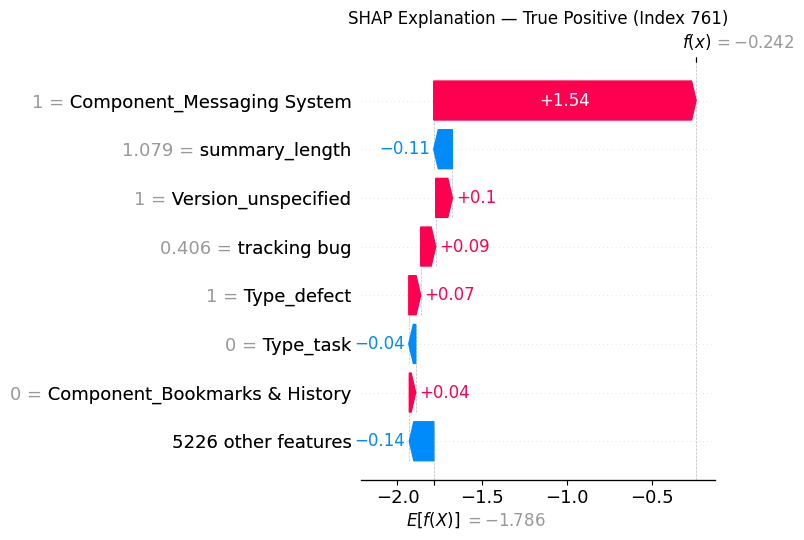

In [ ]:
tp_idx = selected_tp[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[tp_idx],
        base_values=explainer.expected_value,
        data=X_test_final[tp_idx].toarray().flatten(),
        feature_names=feature_names
    ),
    max_display=8,
    show=False
)

plt.title(
    f"SHAP Explanation — True Positive (Index {tp_idx})"
)

plt.tight_layout()



plt.show()

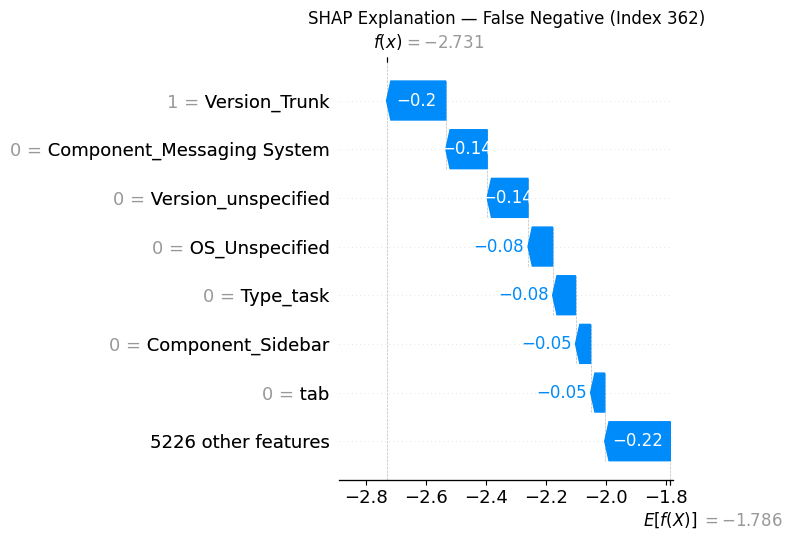

In [ ]:
fn_idx = selected_fn[0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fn_idx],
        base_values=explainer.expected_value,
        data=X_test_final[fn_idx].toarray().flatten(),
        feature_names=feature_names
    ),
    max_display=8,
    show=False
)

plt.title(
    f"SHAP Explanation — False Negative (Index {fn_idx})"
)

plt.tight_layout()


plt.show()

In [ ]:
tp_table = pd.concat(
    [
        df.assign(
            Prediction_Type="True Positive",
            Test_Index=idx
        )
        for idx, df in tp_explanations.items()
    ],
    ignore_index=True
)

fn_table = pd.concat(
    [
        df.assign(
            Prediction_Type="False Negative",
            Test_Index=idx
        )
        for idx, df in fn_explanations.items()
    ],
    ignore_index=True
)

shap_examples = pd.concat(
    [tp_table, fn_table],
    ignore_index=True
)


shap_examples

,Feature,Feature_Value,SHAP_Value,Prediction_Type,Test_Index
0,Component_Messaging System,1.000000,1.544785,True Positive,761
1,summary_length,1.078598,-0.109763,True Positive,761
2,Version_unspecified,1.000000,0.098144,True Positive,761
3,tracking bug,0.406340,0.088413,True Positive,761
4,Type_defect,1.000000,0.070025,True Positive,761
5,Type_task,0.000000,-0.040622,True Positive,761
6,Component_Bookmarks & History,0.000000,0.037553,True Positive,761
7,Version_Trunk,0.000000,0.035974,True Positive,761
8,Component_Messaging System,1.000000,1.516490,True Positive,1900
9,targeting,0.544215,0.365128,True Positive,1900


## Limitations

- Historical Bugzilla priorities may contain subjective or inconsistent human decisions, so the model may inherit historical triage bias.
- TF-IDF captures lexical patterns but has limited semantic understanding of differently worded bugs.
- The 10:1 FN/FP cost ratio is an explicit modeling assumption and should be calibrated with real operational costs before production deployment.
- The binary definition **P1/P2 = Urgent** is a product framing decision rather than an objective property of the original dataset.
- The model should be monitored for changes in bug types, components, and priority distributions after deployment.
- Predicted probabilities were not explicitly calibrated (e.g., via Platt scaling or isotonic regression); the chosen thresholds assume the model's probability outputs are reasonably well-calibrated.

## Conclusion

- The project evolved from exact P1–P5 prediction toward a more actionable **urgent-bug triage system**.  
- The final analysis shows that threshold selection and asymmetric error costs are more relevant to deployment than maximizing overall accuracy.

The key deployment trade-off is:

**0.097 threshold → 80.07% urgent recall at 48% urgent-routing rate**

versus

**0.08 threshold → 87.29% urgent recall and lower modeled cost under the assumed 10:1 FN/FP penalty.**

- The system is therefore best positioned as a **human-in-the-loop triage assistant**, where the threshold can be adjusted according to the organization's tolerance for missed urgent bugs versus additional manual review.
- Recommendation:  I'm going with 0.097 as my default threshold since '80% recall' is an easy target to explain to a team, versus the 0.08 threshold which depends on a cost ratio (10:1). I basically assumed rather than measured.
- I kept the cost-based version in too, just to show the trade-off — but I wouldn't fully trust it until someone gives me real cost numbers to plug in instead of my guess.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import joblib

project_path = "/content/drive/MyDrive/Bug-Prioritization-System"
save_path = os.path.join(project_path, "saved_models")

os.makedirs(save_path, exist_ok=True)

joblib.dump(best_xgb, os.path.join(save_path, "model.pkl"))
joblib.dump(binary_model,os.path.join(save_path, "binary_model.pkl"))
joblib.dump(binary_proba, os.path.join(save_path, "binary_label_encoder.pkl"))
joblib.dump(tfidf, os.path.join(save_path, "tfidf.pkl"))
joblib.dump(encoder, os.path.join(save_path, "encoder.pkl"))
joblib.dump(scaler, os.path.join(save_path, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(save_path, "label_encoder.pkl"))

metadata = {
    "types": sorted(df["Type"].dropna().unique().tolist()),
    "components": sorted(df["Component"].dropna().unique().tolist()),
    "os": sorted(df["OS"].dropna().unique().tolist()),
    "versions": sorted(df["Version"].dropna().unique().tolist()),


    # -----------------------------
    # Regular split model metrics
    # -----------------------------

    "multiclass_accuracy": 0.6675,
    "multiclass_macro_f1": 0.3256,

    # -----------------------------
    # Binary model
    # -----------------------------

    "binary_accuracy": 0.8590,

    "urgent_precision_default": 0.5714,
    "urgent_recall_default": 0.1237,
    "urgent_f1_default": 0.2034,

    # -----------------------------
    # Thresholds
    # -----------------------------

    "default_threshold": 0.50,

    "urgent_recall_threshold": 0.096998,

    "cost_minimizing_threshold": 0.08,

    # -----------------------------
    # Business assumptions
    # -----------------------------

    "fn_cost": 10,
    "fp_cost": 1,

    # -----------------------------
    # Product operating point
    # -----------------------------

    "recall_target": 0.80,

    "recall_target_precision": 0.2435,
    "recall_target_recall": 0.8007
}

joblib.dump(metadata, os.path.join(save_path, "metadata.pkl"))

print(" All files saved to Google Drive!")

In [ ]:
deployment_config = {
    "recall_threshold": 0.096998036,
    "cost_threshold": 0.08,
    "fn_cost": FN_COST,
    "fp_cost": FP_COST
}

joblib.dump(
    deployment_config,
    os.path.join(
        save_path,
        "deployment_config.pkl"
    )
)

print("Deployment configuration saved.")

In [ ]:
os.listdir(save_path)

In [ ]:
base = "/content/drive/MyDrive/Bug-Prioritization-System"

folders = [
    "saved_models",
    "pages",
    "data",
    "images"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Folders created successfully!")